In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
employee = pd.read_csv("/content/employee_tasks_dataset_3.csv")
employee.head()

,employee_id,task_id,task_type,task_given_date,days_to_deadline,priority,original_completed_days,actual_hours_to_complete,is_completed,rating,perceived_difficulty,primary_skill_matching,secondary_skill_matching,ternary_skill_matching,volume_metric,dependency_score,error_risk
0,EMP_001,TSK_0000001,Code Review,2024-04-07,20.0,Low,4.0,26.0,1.0,5.0,2.0,0.82,0.41,0.07,3.0,3.0,2.0
1,EMP_001,TSK_0000002,Bug Fix,2026-05-26,20.0,Low,NaN,NaN,0.0,NaN,2.0,0.71,0.45,0.17,2.0,3.0,3.0
2,EMP_001,TSK_0000003,Feature Development,2026-03-04,14.0,High,NaN,NaN,0.0,NaN,5.0,0.69,0.20,0.03,5.0,2.0,3.0
3,EMP_001,TSK_0000004,Feature Development,2024-07-18,18.0,Medium,2.4,22.4,1.0,5.0,2.0,0.69,0.41,0.14,2.0,2.0,2.0
4,EMP_001,TSK_0000005,Code Review,2025-04-09,12.0,Medium,1.1,8.3,1.0,5.0,1.0,0.80,0.37,0.12,1.0,2.0,0.0


In [3]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165290 entries, 0 to 165289
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   employee_id               165290 non-null  object 
 1   task_id                   165290 non-null  object 
 2   task_type                 165290 non-null  object 
 3   task_given_date           165289 non-null  object 
 4   days_to_deadline          165289 non-null  float64
 5   priority                  165289 non-null  object 
 6   original_completed_days   128589 non-null  float64
 7   actual_hours_to_complete  128589 non-null  float64
 8   is_completed              165289 non-null  float64
 9   rating                    128589 non-null  float64
 10  perceived_difficulty      165289 non-null  float64
 11  primary_skill_matching    165289 non-null  float64
 12  secondary_skill_matching  165289 non-null  float64
 13  ternary_skill_matching    165289 non-null  f

In [4]:
employee.describe()

,days_to_deadline,original_completed_days,actual_hours_to_complete,is_completed,rating,perceived_difficulty,primary_skill_matching,secondary_skill_matching,ternary_skill_matching,volume_metric,dependency_score,error_risk
count,165289.000000,128589.000000,128589.000000,165289.000000,128589.000000,165289.000000,165289.000000,165289.000000,165289.000000,165289.000000,165289.000000,165289.000000
mean,13.990453,3.084863,22.384845,0.777965,4.574292,2.038291,0.713990,0.357529,0.119325,2.430797,1.941636,1.841544
std,5.315802,2.389650,14.922981,0.415616,0.627669,1.142567,0.160166,0.159929,0.087983,1.210986,0.973333,1.082392
min,3.000000,0.500000,0.500000,0.000000,1.100000,0.000000,0.050000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,10.000000,1.400000,11.000000,1.000000,4.200000,1.000000,0.610000,0.240000,0.050000,1.000000,1.000000,1.000000
50%,14.000000,2.400000,18.900000,1.000000,5.000000,2.000000,0.740000,0.350000,0.100000,2.000000,2.000000,2.000000
75%,18.000000,4.100000,30.100000,1.000000,5.000000,3.000000,0.840000,0.470000,0.160000,3.000000,3.000000,3.000000
max,28.000000,16.200000,88.700000,1.000000,5.000000,5.000000,1.000000,0.940000,0.720000,5.000000,5.000000,5.000000


In [5]:
employee.duplicated().sum()

np.int64(0)

In [6]:
employee.shape

(165290, 17)

In [7]:
cols=employee.columns
for col in cols:
  print(col)

employee_id
task_id
task_type
task_given_date
days_to_deadline
priority
original_completed_days
actual_hours_to_complete
is_completed
rating
perceived_difficulty
primary_skill_matching
secondary_skill_matching
ternary_skill_matching
volume_metric
dependency_score
error_risk


In [8]:
cat_cols=employee.select_dtypes(include="object").columns
for col in cat_cols:
  print(col)

employee_id
task_id
task_type
task_given_date
priority


In [9]:
num_cols=employee.select_dtypes(exclude="object").columns
for col in num_cols:
  print(col)

days_to_deadline
original_completed_days
actual_hours_to_complete
is_completed
rating
perceived_difficulty
primary_skill_matching
secondary_skill_matching
ternary_skill_matching
volume_metric
dependency_score
error_risk


In [10]:
correlation_matrix = employee.select_dtypes(include='number').corr()
correlation_matrix

,days_to_deadline,original_completed_days,actual_hours_to_complete,is_completed,rating,perceived_difficulty,primary_skill_matching,secondary_skill_matching,ternary_skill_matching,volume_metric,dependency_score,error_risk
days_to_deadline,1.000000,0.272980,0.318290,0.025261,0.171033,0.213926,0.001640,0.003992,0.002023,0.343966,0.075517,0.108138
original_completed_days,0.272980,1.000000,0.940668,NaN,-0.677680,0.588068,-0.047337,-0.022354,-0.017407,0.758305,0.206117,0.303205
actual_hours_to_complete,0.318290,0.940668,1.000000,NaN,-0.635906,0.702287,-0.058984,-0.027040,-0.018555,0.901961,0.244218,0.361988
is_completed,0.025261,NaN,NaN,1.000000,NaN,-0.039963,0.006558,0.002635,0.003134,-0.043187,-0.012114,-0.020406
rating,0.171033,-0.677680,-0.635906,NaN,1.000000,-0.492870,0.219156,0.108665,0.068560,-0.475704,-0.227024,-0.448849
perceived_difficulty,0.213926,0.588068,0.702287,-0.039963,-0.492870,1.000000,-0.273054,-0.135714,-0.086392,0.627787,0.349035,0.557480
primary_skill_matching,0.001640,-0.047337,-0.058984,0.006558,0.219156,-0.273054,1.000000,0.502620,0.306400,0.001861,-0.094569,-0.349291
secondary_skill_matching,0.003992,-0.022354,-0.027040,0.002635,0.108665,-0.135714,0.502620,1.000000,0.608116,0.004650,-0.048528,-0.173877
ternary_skill_matching,0.002023,-0.017407,-0.018555,0.003134,0.068560,-0.086392,0.306400,0.608116,1.000000,0.001774,-0.031291,-0.107137
volume_metric,0.343966,0.758305,0.901961,-0.043187,-0.475704,0.627787,0.001861,0.004650,0.001774,1.000000,0.220414,0.314143


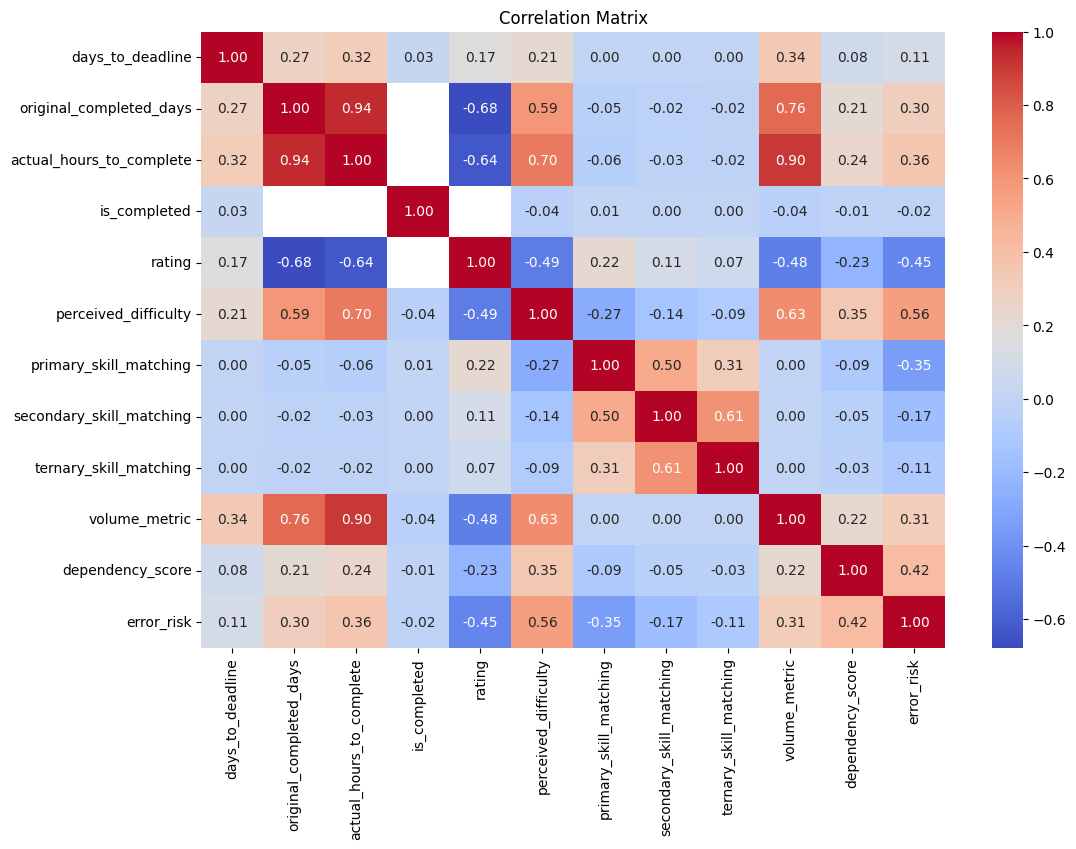

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [12]:
rating_corr = correlation_matrix['rating'].sort_values(ascending=False)
rating_corr

,rating
rating,1.000000
primary_skill_matching,0.219156
days_to_deadline,0.171033
secondary_skill_matching,0.108665
ternary_skill_matching,0.068560
dependency_score,-0.227024
error_risk,-0.448849
volume_metric,-0.475704
perceived_difficulty,-0.492870
actual_hours_to_complete,-0.635906


In [13]:
corr_pairs = correlation_matrix.where(
    ~np.tril(np.ones(correlation_matrix.shape)).astype(bool)
).stack()

corr_pairs = corr_pairs.sort_values(
    key=abs,
    ascending=False
)

corr_pairs

,,0
original_completed_days,actual_hours_to_complete,0.940668
actual_hours_to_complete,volume_metric,0.901961
original_completed_days,volume_metric,0.758305
actual_hours_to_complete,perceived_difficulty,0.702287
original_completed_days,rating,-0.677680
...,...,...
is_completed,secondary_skill_matching,0.002635
days_to_deadline,ternary_skill_matching,0.002023
primary_skill_matching,volume_metric,0.001861
ternary_skill_matching,volume_metric,0.001774


In [14]:
print("Employees:", employee['employee_id'].nunique())
print("Tasks:", employee['task_id'].nunique())

Employees: 17
Tasks: 165290


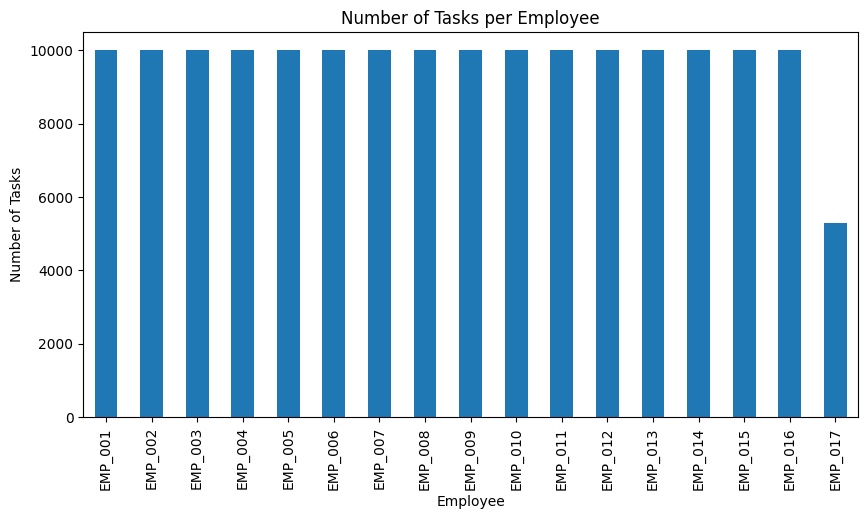

In [15]:
employee['employee_id'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Number of Tasks per Employee')
plt.xlabel('Employee')
plt.ylabel('Number of Tasks')
plt.show()

In [16]:
for col in employee.columns:
    print(col)
    print(employee[col].value_counts(dropna=False).head(10))
    print()

employee_id
employee_id
EMP_001    10000
EMP_002    10000
EMP_003    10000
EMP_004    10000
EMP_005    10000
EMP_006    10000
EMP_007    10000
EMP_008    10000
EMP_009    10000
EMP_010    10000
Name: count, dtype: int64

task_id
task_id
TSK_0165290    1
TSK_0000001    1
TSK_0000002    1
TSK_0000003    1
TSK_0000004    1
TSK_0000005    1
TSK_0000006    1
TSK_0000007    1
TSK_0000008    1
TSK_0000009    1
Name: count, dtype: int64

task_type
task_type
Bug Fix                41366
Code Review            33134
Feature Development    32801
Documentation          24849
Data Pipeline          16764
System Maintenance     16375
Syste                      1
Name: count, dtype: int64

task_given_date
task_given_date
2025-12-27    226
2024-04-29    225
2025-05-01    224
2024-05-13    220
2024-12-31    220
2025-09-22    218
2026-05-18    217
2025-03-02    217
2024-03-03    216
2025-12-24    216
Name: count, dtype: int64

days_to_deadline
days_to_deadline
16.0    12247
15.0    12064
14.0    11067
1

In [17]:
missing = employee.isna().sum()
missing_percent = employee.isna().mean() * 100

missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})

missing_table

,Missing Count,Missing Percentage
employee_id,0,0.000000
task_id,0,0.000000
task_type,0,0.000000
task_given_date,1,0.000605
days_to_deadline,1,0.000605
priority,1,0.000605
original_completed_days,36701,22.204005
actual_hours_to_complete,36701,22.204005
is_completed,1,0.000605
rating,36701,22.204005


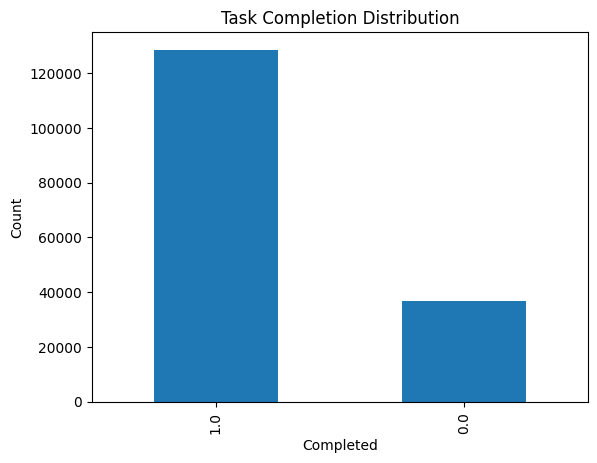

In [18]:
employee['is_completed'].value_counts(normalize=True) * 100

employee['is_completed'].value_counts().plot(kind='bar')
plt.title('Task Completion Distribution')
plt.xlabel('Completed')
plt.ylabel('Count')
plt.show()

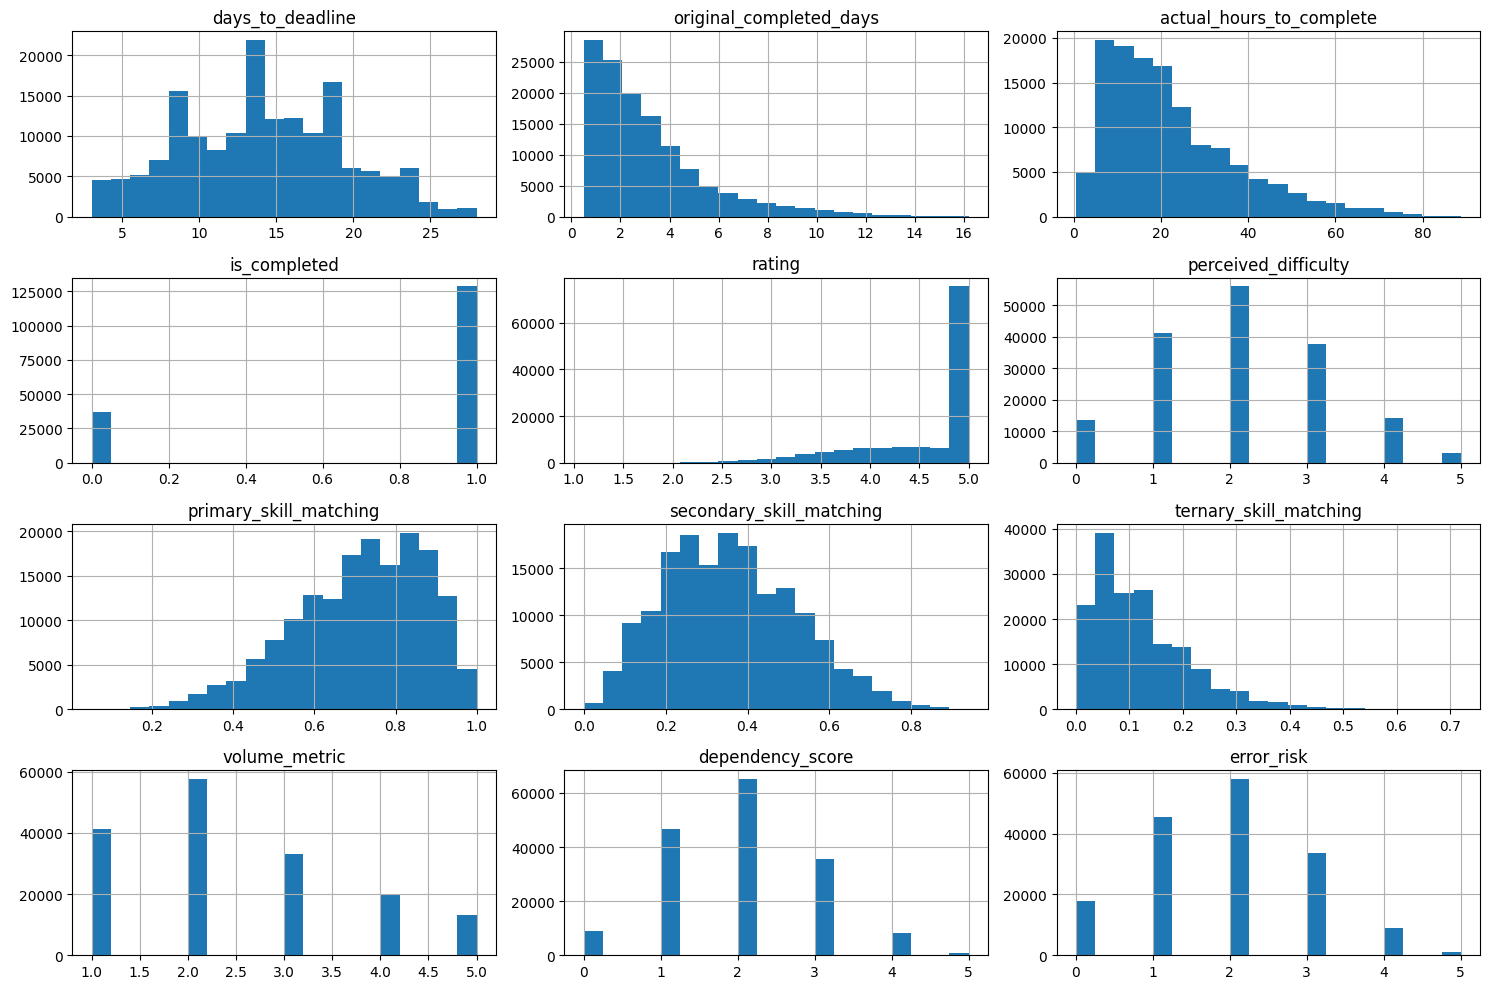

In [19]:
employee.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

In [20]:
employee['rating'].value_counts(dropna=False)

,count
rating,
5.0,72486
NaN,36701
4.5,3435
4.4,3416
4.3,3383
4.2,3317
4.6,3284
4.7,3263
4.8,3247


In [21]:
employee["rating"].describe()

,rating
count,128589.000000
mean,4.574292
std,0.627669
min,1.100000
25%,4.200000
50%,5.000000
75%,5.000000
max,5.000000


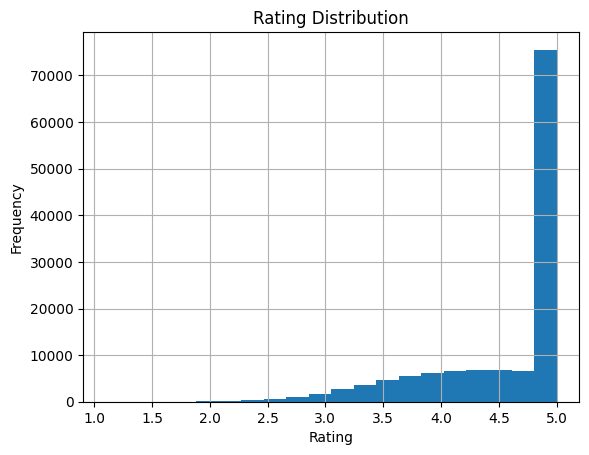

In [22]:
employee['rating'].hist(bins=20)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

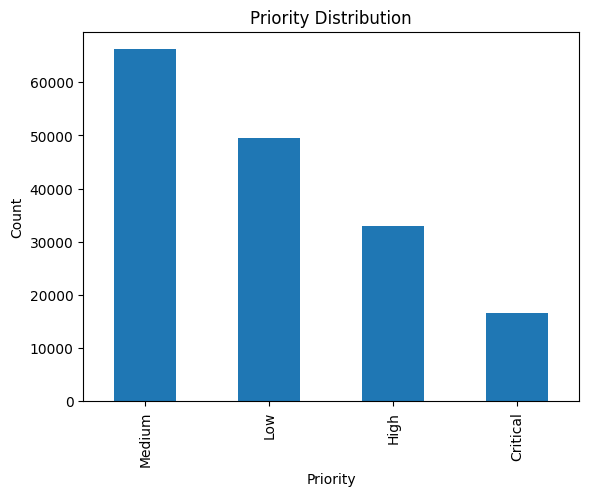

In [23]:
employee['priority'].value_counts().plot(kind='bar')

plt.title('Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.show()

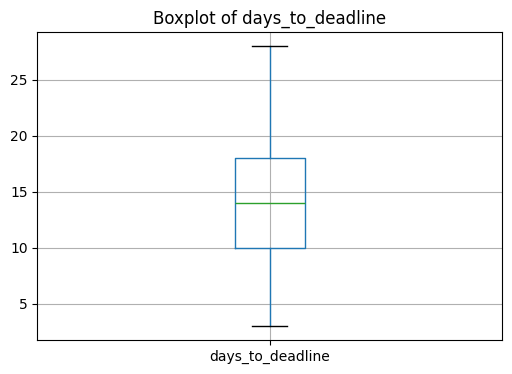

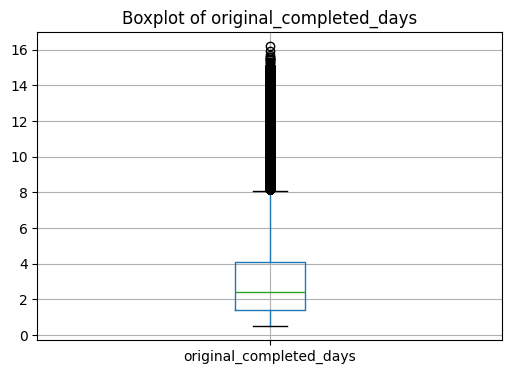

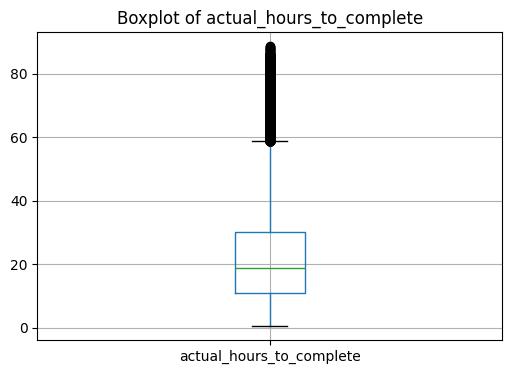

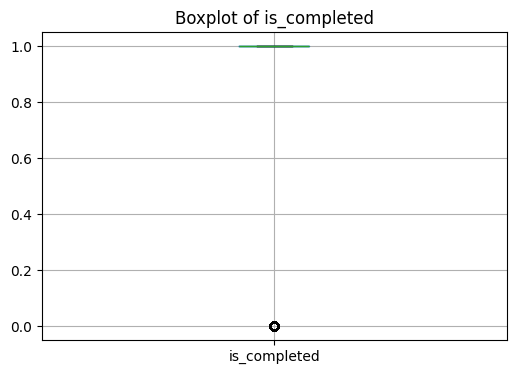

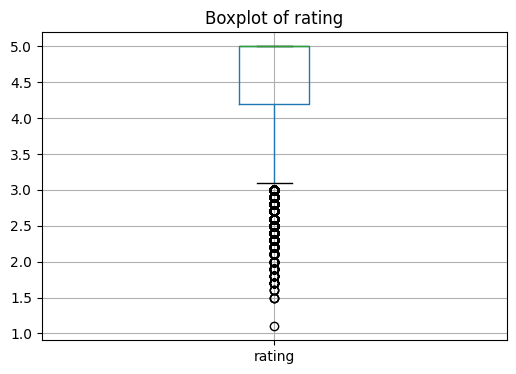

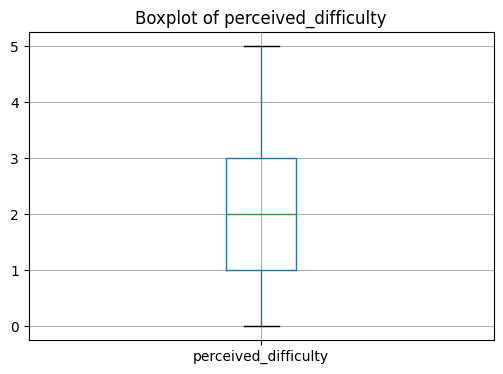

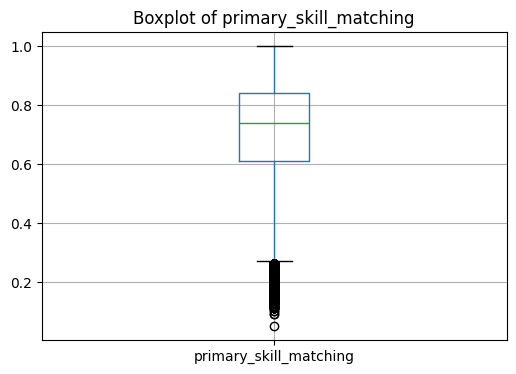

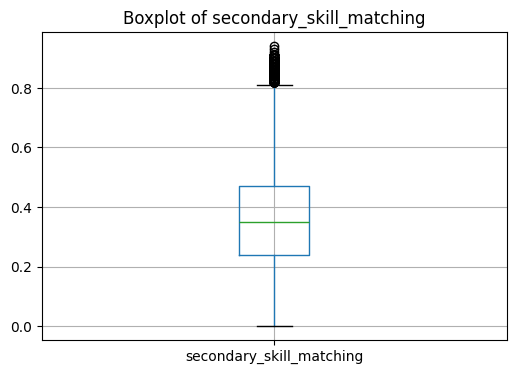

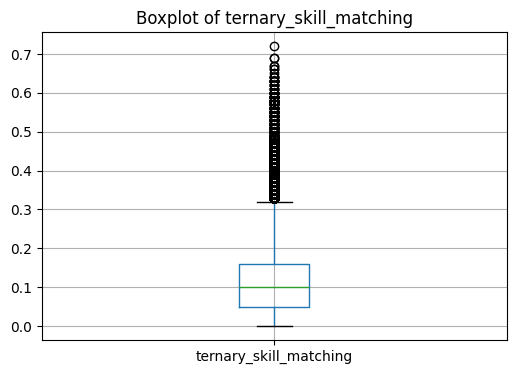

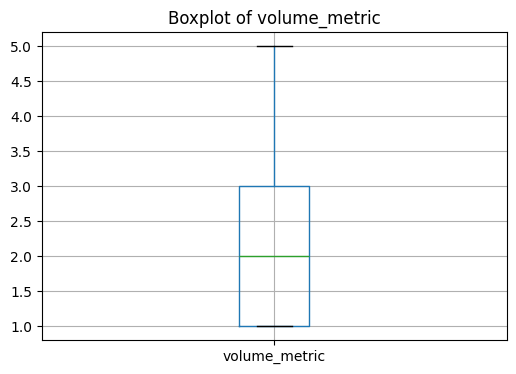

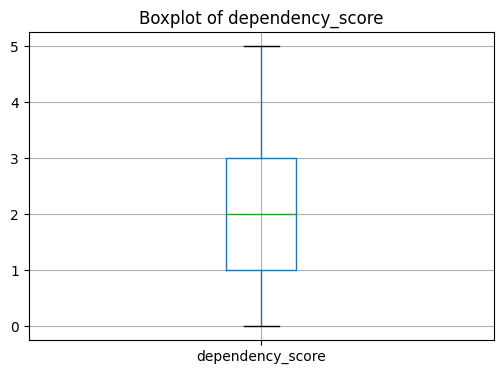

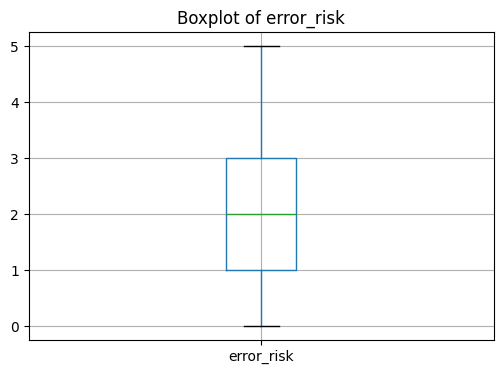

In [24]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    employee.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

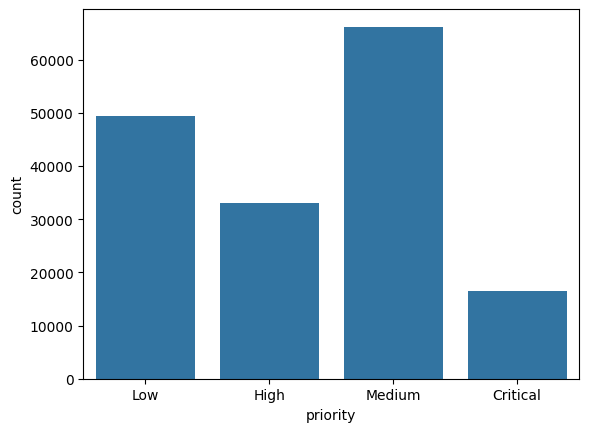

In [25]:
sns.countplot(data=employee, x='priority')
plt.show()

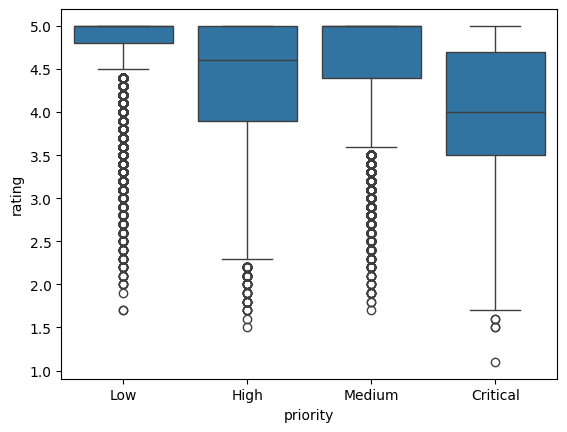

In [26]:
sns.boxplot(data=employee, x='priority', y='rating')
plt.show()

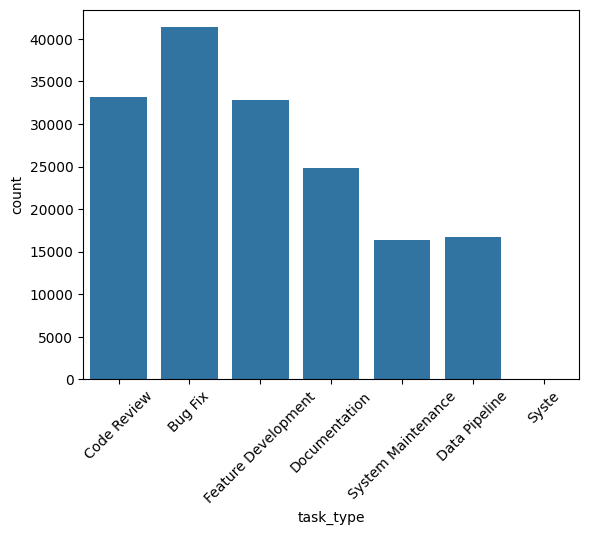

In [27]:
sns.countplot(data=employee, x='task_type')
plt.xticks(rotation=45)
plt.show()

In [28]:
pd.crosstab(employee['priority'], employee['is_completed'], normalize='index') * 100

is_completed,0.0,1.0
priority,,
Critical,27.521718,72.478282
High,23.290411,76.709589
Low,20.573795,79.426205
Medium,21.548638,78.451362


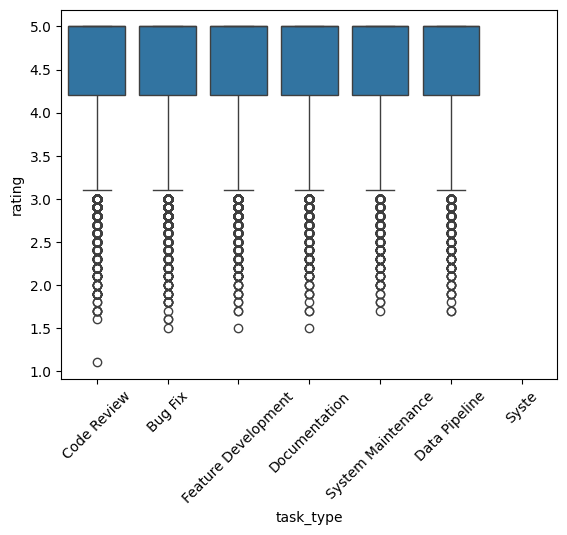

In [29]:
sns.boxplot(data=employee,x="task_type",y="rating")
plt.xticks(rotation=45)
plt.show()

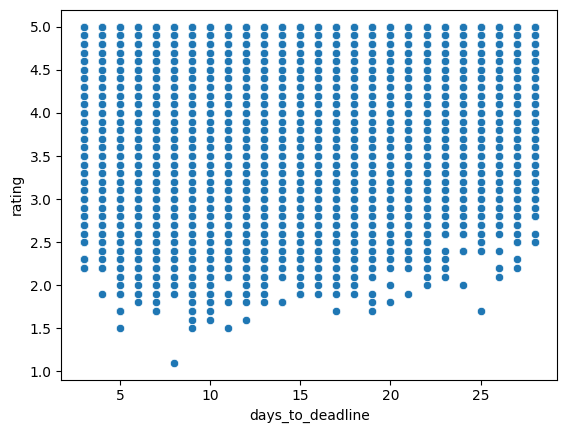

In [30]:
sns.scatterplot(data=employee,x="days_to_deadline",y="rating")
plt.show()

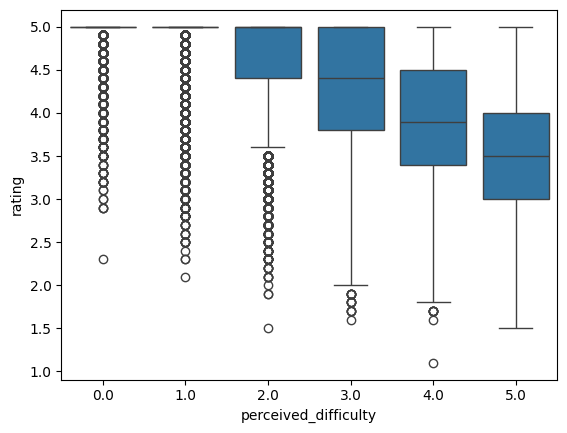

In [31]:
sns.boxplot(data=employee, x='perceived_difficulty', y='rating')
plt.show()

In [32]:
employee_performance = employee.groupby('employee_id').agg(
    avg_rating=('rating', 'mean'),
    completion_rate=('is_completed', 'mean'),
    avg_completion_days=('original_completed_days', 'mean'),
    avg_hours=('actual_hours_to_complete', 'mean'),
    avg_error_risk=('error_risk', 'mean')).reset_index()

employee_performance.head()

,employee_id,avg_rating,completion_rate,avg_completion_days,avg_hours,avg_error_risk
0,EMP_001,4.555763,0.7731,3.084025,22.787971,1.8518
1,EMP_002,4.840454,0.7967,1.723359,16.970190,1.8460
2,EMP_003,4.768913,0.7910,2.098104,18.835272,1.8526
3,EMP_004,4.702236,0.7870,2.405260,20.125006,1.8518
4,EMP_005,4.347355,0.7657,4.209299,26.724984,1.8438


In [33]:
top_employees = employee_performance.sort_values(
    'avg_rating', ascending=False).head(10)

top_employees

,employee_id,avg_rating,completion_rate,avg_completion_days,avg_hours,avg_error_risk
11,EMP_012,4.853721,0.799500,1.660513,16.390919,1.824400
1,EMP_002,4.840454,0.796700,1.723359,16.970190,1.846000
7,EMP_008,4.816744,0.792500,1.864215,17.700366,1.858800
12,EMP_013,4.793060,0.795400,1.916633,18.006726,1.851100
2,EMP_003,4.768913,0.791000,2.098104,18.835272,1.852600
9,EMP_010,4.768715,0.792700,2.119932,18.852012,1.831300
3,EMP_004,4.702236,0.787000,2.405260,20.125006,1.851800
8,EMP_009,4.698078,0.790900,2.385927,20.081869,1.841500
0,EMP_001,4.555763,0.773100,3.084025,22.787971,1.851800
16,EMP_017,4.487394,0.778408,3.437600,24.325261,1.838533


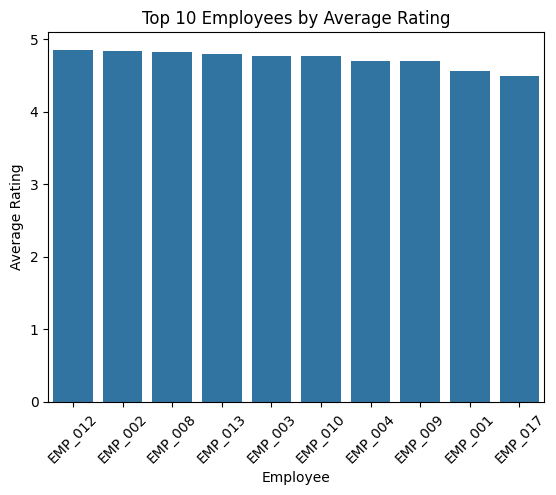

In [34]:
sns.barplot(data=top_employees, x='employee_id', y='avg_rating')
plt.xticks(rotation=45)
plt.title('Top 10 Employees by Average Rating')
plt.xlabel('Employee')
plt.ylabel('Average Rating')
plt.show()